Berechnet die Cosinus-Ähnlichkeit von Sponsoren zueinander anhand ihrer TFIDF-Vektoren.

In [1]:
import pandas as pd
from collections import Counter
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [2]:
ENGLISH_STOP_WORDS

frozenset({'a',
           'about',
           'above',
           'across',
           'after',
           'afterwards',
           'again',
           'against',
           'all',
           'almost',
           'alone',
           'along',
           'already',
           'also',
           'although',
           'always',
           'am',
           'among',
           'amongst',
           'amoungst',
           'amount',
           'an',
           'and',
           'another',
           'any',
           'anyhow',
           'anyone',
           'anything',
           'anyway',
           'anywhere',
           'are',
           'around',
           'as',
           'at',
           'back',
           'be',
           'became',
           'because',
           'become',
           'becomes',
           'becoming',
           'been',
           'before',
           'beforehand',
           'behind',
           'being',
           'below',
           'beside',
           'besides'

In [3]:
text_df = pd.read_parquet("/Users/lmeyer/Programmierung DH/Projektarbeit_YT/scripts/sponsors_and_text.parquet")

In [4]:
text_df.query("sponsor == 'ddbeyond'")

,video_id,sponsor,sponsor_ents,raw_entities,known_entities,id,channel_id,channel_title,title,description,published_at,view_count,default_language,topic_categories,subtitles,snippet,statistics,sponsor_text,combined_text
1298,BzHkVh80kVQ,ddbeyond,"[ddbeyond, dbeyond, dbeyond]","[D&D Beyond, D, D Beyond, D Beyond]",None,BzHkVh80kVQ,UCpXBGqwsBkpvcYjsJBQ7LEQ,Critical Role,"Refjorged | Critical Role | Campaign 2, Episod...",Join us in combating the fires in the Amazon b...,2019-08-26T19:00:02Z,3351907,en,"[https://en.wikipedia.org/wiki/Action_game, ht...","[{'duration_ms': 1941.0, 'start_ms': 451, 'tex...","{'categoryId': '20', 'channelId': 'UCpXBGqwsBk...","{'commentCount': '6742', 'favoriteCount': '0',...","MATT: All righty, so, before we jump into toni...","MATT: All righty, so, before we jump into toni..."
1553,CQWv6zQZTGo,ddbeyond,"[ddbeyond, beyond, criticalrole]","[D&D Beyond, Beyond, Twitch, Critical Role]",None,CQWv6zQZTGo,UCpXBGqwsBkpvcYjsJBQ7LEQ,Critical Role,"Intervention | Critical Role | Campaign 2, Epi...",Our very own Matt Mercer is running a mini adv...,2019-05-20T19:00:02Z,3040554,en,"[https://en.wikipedia.org/wiki/Action_game, ht...","[{'duration_ms': 1439.0, 'start_ms': 131, 'tex...","{'categoryId': '20', 'channelId': 'UCpXBGqwsBk...","{'commentCount': '4021', 'favoriteCount': '0',...","MATT: (laughs) Good. That's good, that was goo...","MATT: (laughs) Good. That's good, that was goo..."
2374,DhlfFwDOwPM,ddbeyond,"[cortex, cortex, fandom, ddbeyond, darringtonp...","[Cortex, Cortex, Fandom, D&D Beyond, Darringto...",None,DhlfFwDOwPM,UCpXBGqwsBkpvcYjsJBQ7LEQ,Critical Role,Under Timeless Ice | Critical Role | Campaign ...,This episode is sponsered by our friends at Fa...,2020-11-16T20:00:02Z,2295755,en,"[https://en.wikipedia.org/wiki/Action_game, ht...","[{'duration_ms': 2751.0, 'start_ms': 240, 'tex...","{'categoryId': '20', 'channelId': 'UCpXBGqwsBk...","{'commentCount': '3553', 'favoriteCount': '0',...",MATT: Just like that. Before we get into tonig...,MATT: Just like that. Before we get into tonig...
3357,FJ25t2cM6Ws,ddbeyond,"[ddbeyond, beyond, ddbeyond]","[D&D Beyond, Beyond, D&D Beyond]",None,FJ25t2cM6Ws,UCpXBGqwsBkpvcYjsJBQ7LEQ,Critical Role,"Commerce & Chaos | Critical Role | Campaign 2,...",The Mighty Nein take two weeks of down time in...,2019-12-20T00:26:10Z,2276456,en,[https://en.wikipedia.org/wiki/Strategy_video_...,"[{'duration_ms': 3071.0, 'start_ms': 0, 'text'...","{'categoryId': '20', 'channelId': 'UCpXBGqwsBk...","{'commentCount': '2817', 'favoriteCount': '0',...",MATT: Laura will be joining us shortly. She's ...,MATT: Laura will be joining us shortly. She's ...
4576,HNODkS9gZmM,ddbeyond,"[ddbeyond, ddbeyond]","[D&D Beyond, D&D Beyond]",None,HNODkS9gZmM,UCpXBGqwsBkpvcYjsJBQ7LEQ,Critical Role,"Chases and Trees | Critical Role | Campaign 2,...",The Mighty Nein continue their trudge through ...,2019-06-03T19:00:05Z,3197234,en,[https://en.wikipedia.org/wiki/Video_game_cult...,"[{'duration_ms': 1816.0, 'start_ms': 596, 'tex...","{'categoryId': '20', 'channelId': 'UCpXBGqwsBk...","{'commentCount': '3678', 'favoriteCount': '0',...",MATT: The evolution of that still escapes me. ...,MATT: The evolution of that still escapes me. ...
4821,HoZGMqCIRK8,ddbeyond,"[projectatedensgate, ddbeyond, ddbeyond]","[Project at Eden's Gate, D&D Beyond, D&D Beyond]",None,HoZGMqCIRK8,UCaBf1a-dpIsw8OxqH4ki2Kg,Geek & Sundry,Midnight Espionage | Critical Role: THE MIGHTY...,Hijinks ensue as the Mighty Nein attempt subte...,2018-04-02T19:00:00Z,5539068,en,[https://en.wikipedia.org/wiki/Strategy_video_...,"[{'duration_ms': 3533.0, 'start_ms': 0, 'text'...","{'categoryId': '24', 'channelId': 'UCaBf1a-dpI...","{'commentCount': '5979', 'favoriteCount': '0',...",(cheering) MATT: Before we get into tonight's ...,(cheering) MATT: Before we get into tonight's ...
4871,HtnTlm6UBpg,ddbeyond,"[ddbeyond, masterpiecetheatre]","[D&D Beyond, Masterpiece Theatre]",None,HtnTlm6UBpg,UCaBf1a-dpIsw8OxqH4ki2Kg,Geek & Sundry,Steam and Conversation |

In [5]:
sponsor_stop = set(text_df["sponsor"])
stop_list_custom = list(sponsor_stop | ENGLISH_STOP_WORDS)

In [6]:
text_df.shape

(32173, 19)

In [7]:
# Sponsor-Vorkommen
sponsor_counts = text_df['sponsor'].value_counts()

# Filtern nach min 10 Vorkommen
valid_sponsors = sponsor_counts[sponsor_counts >= 10].index

# Filter anwenden, gruppieren, Texte zusammenfügen
grouped = text_df[text_df['sponsor'].isin(valid_sponsors)].groupby('sponsor')['sponsor_text'].apply(' '.join)

In [8]:
valid_sponsors

Index(['squarespace', 'nordvpn', 'skillshare', 'teespring', 'brilliant',
       'audible', 'surfshark', 'betterhelp', 'nebula', 'raidshadowlegends',
       ...
       'squareenix', 'intotheam', 'parade', 'tradingview', 'linustech',
       'marvelstudios', 'crunchlabs', 'kotak', 'sweetwater', 'gameloft'],
      dtype='object', name='sponsor', length=393)

In [9]:
grouped.head()

sponsor
80000hours       Europa Clipper is a perfect example of the ama...
acysecurities    fine trays I'll give you an update this  eveni...
adamandeve       We haven't told each other any of them. Oh, wa...
adobe            now in full transparency I am an Adobe Express...
airalo           to using the trusty touchcreen for photos anyw...
Name: sponsor_text, dtype: object

In [10]:
vectorizer = TfidfVectorizer(
    stop_words=stop_list_custom,
    lowercase=True,
    token_pattern=r'\b[a-zA-Z]{2,}\b',
    min_df = 2,
    max_df= 0.7
)

tfidf_matrix = vectorizer.fit_transform(grouped)

In [11]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 354331 stored elements and shape (393, 24840)>

In [12]:
similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=grouped.index, columns=grouped.index)

similarity_df

sponsor,80000hours,acysecurities,adamandeve,adobe,airalo,airbnb,airup,aliexpress,alphaprogression,altcoindaily,...,worldofwarships,wren,wyrmwoodgaming,yahahastudio,yahoofinance,yout,zerodha,zippixtoothpicks,zocdoc,zoom
sponsor,,,,,,,,,,,,,,,,,,,,,
80000hours,1.000000,0.007867,0.012664,0.058578,0.017753,0.044382,0.009826,0.020161,0.008479,0.023067,...,0.010968,0.054624,0.002865,0.008237,0.010751,0.027372,0.049017,0.012841,0.046297,0.029110
acysecurities,0.007867,1.000000,0.006778,0.027145,0.022296,0.023444,0.005525,0.023552,0.008342,0.037374,...,0.008114,0.005636,0.014369,0.041351,0.021419,0.024707,0.034238,0.011286,0.011357,0.050750
adamandeve,0.012664,0.006778,1.000000,0.042007,0.021686,0.033102,0.035847,0.051432,0.010258,0.010573,...,0.013095,0.013171,0.029690,0.024940,0.010493,0.046669,0.023249,0.012716,0.042218,0.024449
adobe,0.058578,0.027145,0.042007,1.000000,0.055596,0.125790,0.035542,0.182230,0.018222,0.091896,...,0.053667,0.040654,0.024373,0.156631,0.030849,0.172310,0.118243,0.043059,0.075158,0.121614
airalo,0.017753,0.022296,0.021686,0.055596,1.000000,0.098909,0.023255,0.082135,0.006523,0.072823,...,0.011651,0.010995,0.011051,0.034889,0.022978,0.036484,0.036734,0.012847,0.057372,0.053322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yout,0.027372,0.024707,0.046669,0.172310,0.036484,0.079862,0.064137,0.095893,0.030042,0.036026,...,0.033928,0.038524,0.023667,0.059449,0.023713,1.000000,0.069508,0.054935,0.058752,0.095055
zerodha,0.049017,0.034238,0.023249,0.118243,0.036734,0.110365,0.034780,0.086887,0.008939,0.060489,...,0.019709,0.106715,0.018372,0.111417,0.031122,0.069508,1.000000,0.014967,0.064246,0.064682
zippixtoothpicks,0.012841,0.011286,0.012716,0.043059,0.012847,0.034034,0.016646,0.018982,0.162570,0.022578,...,0.013815,0.018948,0.082741,0.017447,0.023774,0.054935,0.014967,1.000000,0.054917,0.038110


In [13]:
sponsors_count= Counter(text_df["sponsor"])
most_common_sponsors=sponsors_count.most_common(30)
most_common_sponsors=set([n for n, c in most_common_sponsors])
most_common_sponsors

{'athleticgreens',
 'audible',
 'aura',
 'betterhelp',
 'brilliant',
 'curiositystream',
 'factor',
 'groundnews',
 'hellofresh',
 'incogni',
 'intel',
 'keeps',
 'linode',
 'manscaped',
 'nebula',
 'newegg',
 'nordvpn',
 'opera',
 'pcbway',
 'raidshadowlegends',
 'raycon',
 'ridge',
 'shopify',
 'skillshare',
 'squarespace',
 'surfshark',
 'teespring',
 'warthunder',
 'webull',
 'worldanvil'}

In [14]:
subset = similarity_df.loc[
    similarity_df.index.intersection(most_common_sponsors),
    similarity_df.columns.intersection(most_common_sponsors)
]
subset


sponsor,athleticgreens,audible,aura,betterhelp,brilliant,curiositystream,factor,groundnews,hellofresh,incogni,...,raycon,ridge,shopify,skillshare,squarespace,surfshark,teespring,warthunder,webull,worldanvil
sponsor,,,,,,,,,,,,,,,,,,,,,
athleticgreens,1.000000,0.134329,0.094162,0.140474,0.059329,0.061797,0.149291,0.058179,0.144821,0.064102,...,0.065753,0.045558,0.177720,0.083186,0.092914,0.068039,0.177374,0.017743,0.042703,0.039038
audible,0.134329,1.000000,0.193791,0.139609,0.135699,0.247275,0.123178,0.097046,0.142206,0.114422,...,0.137057,0.125849,0.258760,0.232975,0.207712,0.153061,0.384287,0.071794,0.097126,0.103558
aura,0.094162,0.193791,1.000000,0.093845,0.087955,0.107726,0.069568,0.092932,0.091704,0.568966,...,0.081176,0.094131,0.245602,0.140290,0.178904,0.339967,0.330527,0.048892,0.106661,0.083036
betterhelp,0.140474,0.139609,0.093845,1.000000,0.061211,0.075916,0.067866,0.044659,0.080724,0.064539,...,0.059828,0.045639,0.185805,0.100618,0.083450,0.077332,0.212881,0.017248,0.049080,0.044818
brilliant,0.059329,0.135699,0.087955,0.061211,1.000000,0.137061,0.037381,0.068322,0.049318,0.085918,...,0.039029,0.035180,0.115240,0.272435,0.105352,0.064439,0.258694,0.020162,0.052513,0.086598
curiositystream,0.061797,0.247275,0.107726,0.075916,0.137061,1.000000,0.054755,0.073246,0.064559,0.089125,...,0.056853,0.049500,0.152136,0.178024,0.114557,0.156629,0.375400,0.050592,0.067175,0.077804
factor,0.149291,0.123178,0.069568,0.067866,0.037381,0.054755,1.000000,0.034709,0.718935,0.043618,...,0.052833,0.048537,0.123619,0.071805,0.067218,0.049884,0.207252,0.014395,0.066029,0.029461
groundnews,0.058179,0.097046,0.092932,0.044659,0.068322,0.073246,0.034709,1.000000,0.043221,0.062922,...,0.028761,0.030913,0.095436,0.066574,0.098203,0.063967,0.172560,0.029406,0.036622,0.054376
hellofresh,0.144821,0.142206,0.091704,0.080724,0.049318,0.064559,0.718935,0.043221,1.000000,0.056409,...,0.061817,0.068292,0.180079,0.078418,0.100134,0.062219,0.244438,0.018532,0.055919,0.039080


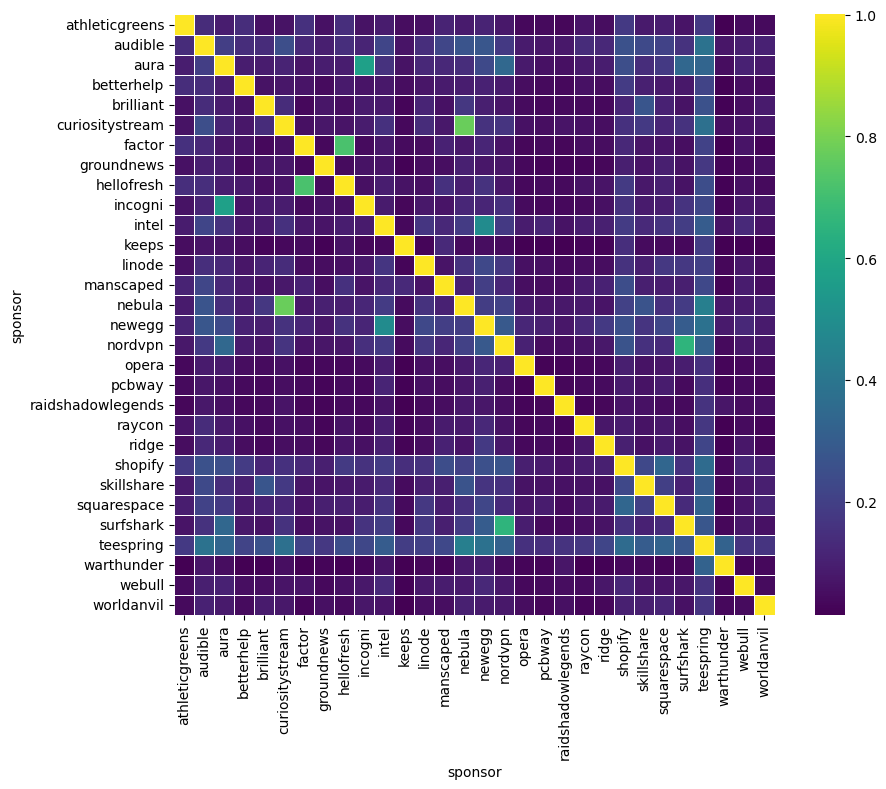

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(subset, annot=False, cmap='viridis', square=True, linewidths=0.5)
#plt.title('Heatmap Sponsor Ähnlichkeit (TF-IDF / Cosinus-Ähnlichkeit)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("similar_sponsor_texts.png", dpi=300)
plt.show()